# 04 — End-to-End Prototype (12 September 2026)
**Initial end-to-end adaptive 2.5D prototype validated on real nuScenes LiDAR data.**
Not a final system; not production-ready; no generalization claimed beyond the tested data.

```text
REAL nuScenes LiDAR -> preprocessing -> semantic/annotation input -> geometric features
 -> PerceptionResult -> RegionFeatures -> Importance Engine -> Resolution Engine
 -> AdaptiveMapCell -> ADAPTIVE 2.5D MAP -> visualization + metrics
```
Sections 9–11 Sept work is reused unchanged (engines frozen, thresholds untouched).


## 1. Environment and project setup


In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.4.4
Pandas: 3.0.2


## 2. Project roots (Colab Drive mount with local fallback — no second project directory)


In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/LiDAR_Hackathon"
except ImportError:
    # Local execution: kernel cwd is notebooks/ -> repo root is its parent.
    # If cwd already holds src/ + data/processed, it IS the repo root.
    _cwd = os.path.abspath(os.getcwd())
    if os.path.isdir(os.path.join(_cwd, "src")) and os.path.isdir(
            os.path.join(_cwd, "data", "processed")):
        PROJECT_ROOT = _cwd
    else:
        PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
    print("Local PROJECT_ROOT:", PROJECT_ROOT)

SRC_ROOT = os.path.join(PROJECT_ROOT, "src")
PROCESSED_ROOT = os.path.join(PROJECT_ROOT, "data", "processed")
RESULTS_ROOT = os.path.join(PROJECT_ROOT, "results")
FIGURES_ROOT = os.path.join(RESULTS_ROOT, "figures")
NUSC_ROOT = os.path.join(PROJECT_ROOT, "data", "raw", "nuscenes")

os.makedirs(RESULTS_ROOT, exist_ok=True)
os.makedirs(FIGURES_ROOT, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_ROOT:", SRC_ROOT)
print("NUSC_ROOT:", NUSC_ROOT)


Local PROJECT_ROOT: c:\Users\SARKAR\Documents\Default Project
PROJECT_ROOT: c:\Users\SARKAR\Documents\Default Project
SRC_ROOT: c:\Users\SARKAR\Documents\Default Project\src
NUSC_ROOT: c:\Users\SARKAR\Documents\Default Project\data\raw\nuscenes


## 3. Import all existing modules (plus `mapper_2_5d` / `visualization`; no duplicates)


In [3]:
# Notebook-03 convention: both SRC_ROOT and PROJECT_ROOT on sys.path,
# imports as `from src.<module> import ...` so package-relative imports
# (`from .data_types`, `from config...`) resolve. Plain `from data_types`
# cannot work with this repo layout.
if SRC_ROOT not in sys.path:
    sys.path.append(SRC_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.data_types import LiDARFrame, PerceptionResult, RegionFeatures
from src.interface_validator import validate_region_features
from src.lidar_loader import load_sample_lidar  # raw .bin loader (processed .npy used below)
from src.preprocessing import preprocess_points  # repo signature: (Nx4) -> (clean, counts)
from src.importance_engine import ImportanceEngine
from src.resolution_engine import ResolutionEngine
from src.semantic_adapter import (
    aggregate_to_regions,
    annotations_to_sensor_frame,
    assign_annotation_semantics,
    build_perception_from_semantics,
)
from src.mapper_2_5d import (
    AdaptiveMapCell,
    build_adaptive_map,
    map_statistics,
    validate_adaptive_map_df,
)
from src.visualization import (
    plot_combined_demo,
    plot_elevation_map,
    plot_importance_map,
    plot_lidar_xy,
    plot_resolution_map,
    plot_semantic_regions,
)

importance_engine = ImportanceEngine()  # default repo config, unchanged
resolution_engine = ResolutionEngine()  # default repo config, unchanged
print("Imports OK — engines on default repo configuration.")


Imports OK — engines on default repo configuration.


## 4. Find processed real frames


In [4]:
processed_files = sorted(
    f for f in os.listdir(PROCESSED_ROOT)
    if f.endswith("_LIDAR_TOP_xyzi.npy")
)
print("Processed frames:", len(processed_files))
print(processed_files[:10])

if not processed_files:
    raise FileNotFoundError("No processed nuScenes LIDAR_TOP frames were found.")

Processed frames: 404
['00889f8a9549450aa2f32cf310a3e305_LIDAR_TOP_xyzi.npy', '0106a9b8e65f4ad1867b44591aeed8b0_LIDAR_TOP_xyzi.npy', '023c4df2d451409881d8e6ea82f14704_LIDAR_TOP_xyzi.npy', '0307afa1ec7e48ce90295acabf8cb6dd_LIDAR_TOP_xyzi.npy', '0373e9d8886648779c8a73304919ab5f_LIDAR_TOP_xyzi.npy', '0402e40724984f3b833496067d46c771_LIDAR_TOP_xyzi.npy', '042f582eb2bb4231910918ba85f390d3_LIDAR_TOP_xyzi.npy', '048a45dd2cf54aa5808d8ccc85731d44_LIDAR_TOP_xyzi.npy', '050b2d9c4bb647b7ab4ee94bdb538e1d_LIDAR_TOP_xyzi.npy', '056becbc0d5a46da8d59eebddedb47bb_LIDAR_TOP_xyzi.npy']


## 5. Select one real frame (N x 4 `[x, y, z, intensity]` contract)


In [5]:
processed_file = processed_files[0]
processed_path = os.path.join(PROCESSED_ROOT, processed_file)
raw_processed_points = np.load(processed_path)
print("Stored processed shape:", raw_processed_points.shape)
assert raw_processed_points.ndim == 2
assert raw_processed_points.shape[1] == 4
assert np.isfinite(raw_processed_points).all()

Stored processed shape: (34658, 4)


## 6. Frame metadata (preserved through to the final output)


In [6]:
sample_token = processed_file.replace("_LIDAR_TOP_xyzi.npy", "")
metadata_path = os.path.join(PROCESSED_ROOT, f"{sample_token}_metadata.csv")
metadata_df = pd.read_csv(metadata_path)
frame_metadata = metadata_df.iloc[0].to_dict()
print("Frame ID:", frame_metadata.get("frame_id"))
print("Sample token:", frame_metadata.get("sample_token"))
print("LiDAR token:", frame_metadata.get("lidar_token"))
print("Timestamp:", frame_metadata.get("timestamp"))

Frame ID: 00889f8a9549450aa2f32cf310a3e305
Sample token: 00889f8a9549450aa2f32cf310a3e305
LiDAR token: 5933b3acbae44b6a92b36327b134e56c
Timestamp: 1535657119649820.0


## 7. Run preprocessing (already-completed module; adapted to the repo signature `preprocess_points`)


In [7]:
# Adapted to the actual repository signature (preprocess_points, not preprocess_lidar).
# Input is the stored processed frame, so this re-run is an idempotence/reliability check.
preprocessed_points, prep_counts = preprocess_points(raw_processed_points)
ring_index = None  # no ring field in the N x 4 contract
assert preprocessed_points.ndim == 2
assert preprocessed_points.shape[1] == 4
assert len(preprocessed_points) > 0
assert np.isfinite(preprocessed_points).all()
print("Input points:", len(raw_processed_points))
print("Processed points:", len(preprocessed_points))
print("Retention ratio:", len(preprocessed_points) / max(len(raw_processed_points), 1))
print("Removal counts:", prep_counts)

Input points: 34658
Processed points: 34658
Retention ratio: 1.0
Removal counts: {'n_raw': 34658, 'n_nonfinite_removed': 0, 'n_zero_range_removed': 0, 'n_outside_roi_removed': 0, 'n_processed': 34658}


## 8. Rajashree — preprocessing reliability (NaN / Inf / zero-range / N x 4 / ROI)


In [8]:
assert np.isfinite(preprocessed_points).all()
distances = np.linalg.norm(preprocessed_points[:, :3], axis=1)
assert np.all(distances > 0)
reliability_row = {
    "frame_id": str(frame_metadata["frame_id"]),
    "sample_token": sample_token,
    "input_points": len(raw_processed_points),
    "processed_points": len(preprocessed_points),
    "removed_points": len(raw_processed_points) - len(preprocessed_points),
    "retention_ratio": len(preprocessed_points) / max(len(raw_processed_points), 1),
    "valid": True,
}
print(reliability_row)

{'frame_id': '00889f8a9549450aa2f32cf310a3e305', 'sample_token': '00889f8a9549450aa2f32cf310a3e305', 'input_points': 34658, 'processed_points': 34658, 'removed_points': 0, 'retention_ratio': 1.0, 'valid': True}


## 9. Build `LiDARFrame`


In [9]:
lidar_frame = LiDARFrame(
    frame_id=str(frame_metadata["frame_id"]),
    timestamp=float(frame_metadata["timestamp"]),
    points=preprocessed_points.astype(np.float32),
)
assert lidar_frame.points.shape[1] == 4
print("LiDARFrame created successfully.")

LiDARFrame created successfully.


## 10. Semantic / annotation input (11 September pipeline, reused)
Source: annotation boxes in sensor frame; points outside boxes stay `unknown`/`fallback`.
Annotation != ML confidence; lidarseg ground truth != model prediction. Nothing is fabricated.


In [10]:
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version="v1.0-mini", dataroot=NUSC_ROOT, verbose=False)
sample = nusc.get("sample", sample_token)
sensor_anns = annotations_to_sensor_frame(nusc, sample)  # global -> ego -> sensor
semantic_labels, semantic_source_arr, _ = assign_annotation_semantics(
    preprocessed_points, sensor_anns
)
confidence = np.full(len(preprocessed_points), np.nan)  # not applicable for non-ML sources
import collections
print("Point labels:", dict(collections.Counter(semantic_labels.tolist())))
print("Point sources:", dict(collections.Counter(semantic_source_arr.tolist())))
semantic_source = "+".join(sorted(set(semantic_source_arr.tolist())))
print("Semantic source:", semantic_source)

Point labels: {'unknown': 27514, 'vehicle': 7114, 'pedestrian_vru': 7, 'static_manmade': 23}
Point sources: {'fallback': 27514, 'annotation': 7144}
Semantic source: annotation+fallback


## 11. Create `PerceptionResult` (length consistency verified)


In [11]:
perception_result, source_array, _ = build_perception_from_semantics(
    str(frame_metadata["frame_id"]), preprocessed_points,
    semantic_labels, semantic_source_arr,
)
for name in ("semantic_labels", "confidence", "distance", "elevation",
             "roughness", "point_density"):
    assert len(getattr(perception_result, name)) == len(preprocessed_points), name
print("PerceptionResult OK:", type(perception_result).__name__)

PerceptionResult OK: PerceptionResult


## 12. Generate region features (2.0 m integration grid — repo-frozen value)


In [12]:
CELL_SIZE = 2.0
region_features, region_details = aggregate_to_regions(
    perception_result, source_array, cell_size=CELL_SIZE
)
print("Spatial regions:", len(region_features))
for region in region_features:
    validate_region_features(region)
print("All regions validated.")

Spatial regions: 410
All regions validated.


## 13. Finalize / freeze Resolution Engine (boundaries verified, NOT retuned)
`importance >= 0.75 -> 0.05 m; >= 0.50 -> 0.10 m; >= 0.25 -> 0.20 m; otherwise 0.50 m`


In [13]:
boundary_values = [0.00, 0.24, 0.25, 0.49, 0.50, 0.74, 0.75, 1.00]
boundary_results = [
    {"importance": v, "resolution_m": resolution_engine.assign_resolution(v)}
    for v in boundary_values
]
display(pd.DataFrame(boundary_results))
expected = {0.00: 0.50, 0.24: 0.50, 0.25: 0.20, 0.49: 0.20,
            0.50: 0.10, 0.74: 0.10, 0.75: 0.05, 1.00: 0.05}
for row in boundary_results:
    assert row["resolution_m"] == expected[row["importance"]]
print("Resolution Engine frozen for today's prototype.")

,importance,resolution_m
0,0.00,0.50
1,0.24,0.50
2,0.25,0.20
3,0.49,0.20
4,0.50,0.10
5,0.74,0.10
6,0.75,0.05
7,1.00,0.05


Resolution Engine frozen for today's prototype.


## 14. Adaptive 2.5D map-cell schema (`src/mapper_2_5d.py::AdaptiveMapCell`)
Fields: x, y, elevation, occupancy, semantic_class, confidence, importance, resolution,
point_count, region_id, semantic_source. Occupancy = evidence-presence indicator (1.0),
NOT probabilistic occupancy.


In [14]:
print(AdaptiveMapCell.__doc__)
import dataclasses
print([f.name for f in dataclasses.fields(AdaptiveMapCell)])

One adaptive 2.5D map cell (first prototype: one region -> one cell).
['x', 'y', 'elevation', 'occupancy', 'semantic_class', 'confidence', 'importance', 'resolution', 'point_count', 'region_id', 'semantic_source']


## 15. Run core mapping logic: RegionFeatures -> importance -> resolution -> AdaptiveMapCell


In [15]:
map_cells, adaptive_map_df = build_adaptive_map(
    region_features, importance_engine, resolution_engine, region_details
)
display(adaptive_map_df.head())
validate_adaptive_map_df(adaptive_map_df)
assert len(adaptive_map_df) == len(region_features)
print("Adaptive cells:", len(map_cells))

,x,y,elevation,occupancy,semantic_class,confidence,importance,resolution,point_count,region_id,semantic_source
0,-26.005449,31.257290,6.680870,1.0,unknown,0.0,0.483018,0.2,1,0,fallback
1,-24.561184,29.479907,4.043361,1.0,unknown,0.0,0.617631,0.1,2,1,fallback
2,-25.032728,31.410625,1.977279,1.0,unknown,0.0,0.577245,0.1,10,2,fallback
3,-22.827494,29.170965,3.270350,1.0,unknown,0.0,0.591599,0.1,9,3,fallback
4,-22.868874,31.086550,1.603764,1.0,unknown,0.0,0.540869,0.1,14,4,fallback


Adaptive cells: 410


## 16. Visualize raw LiDAR + semantic + importance + resolution + elevation (reusable `visualization.py`)


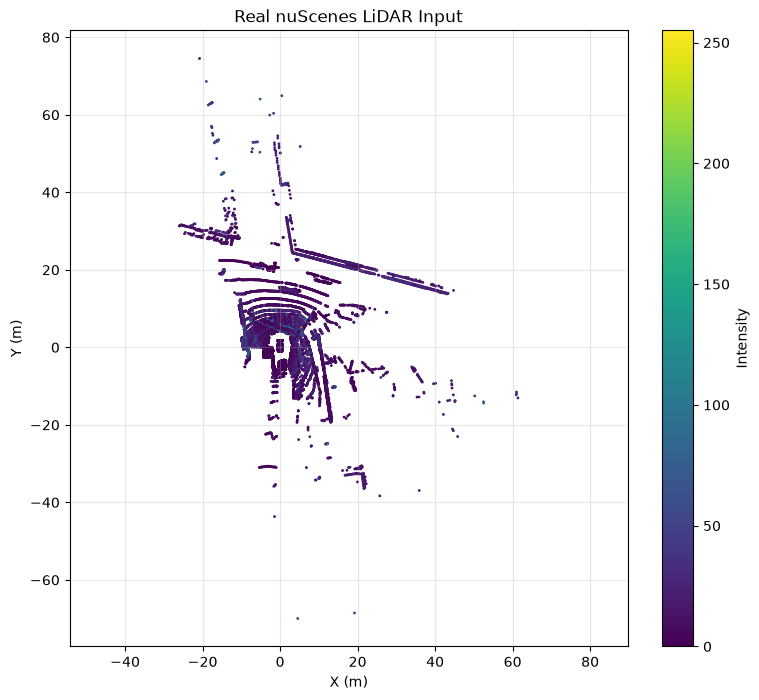

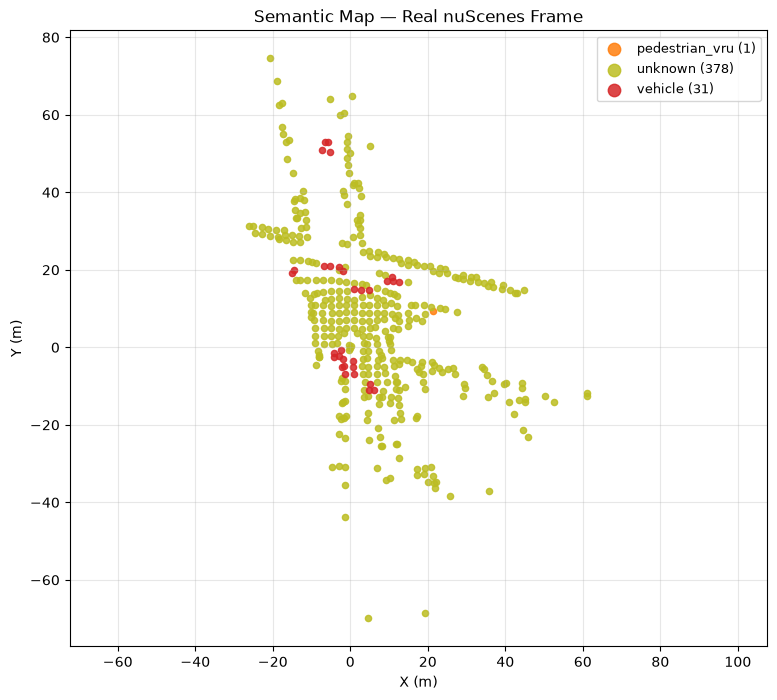

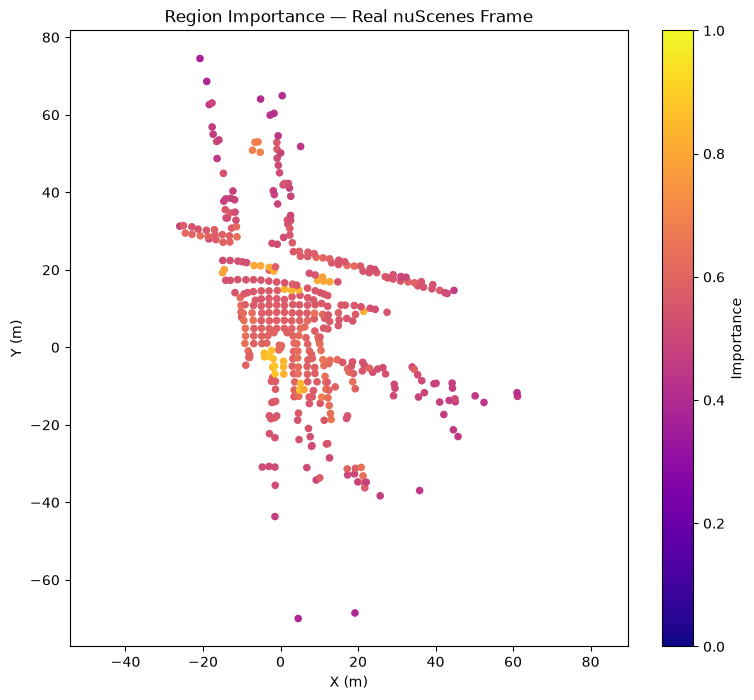

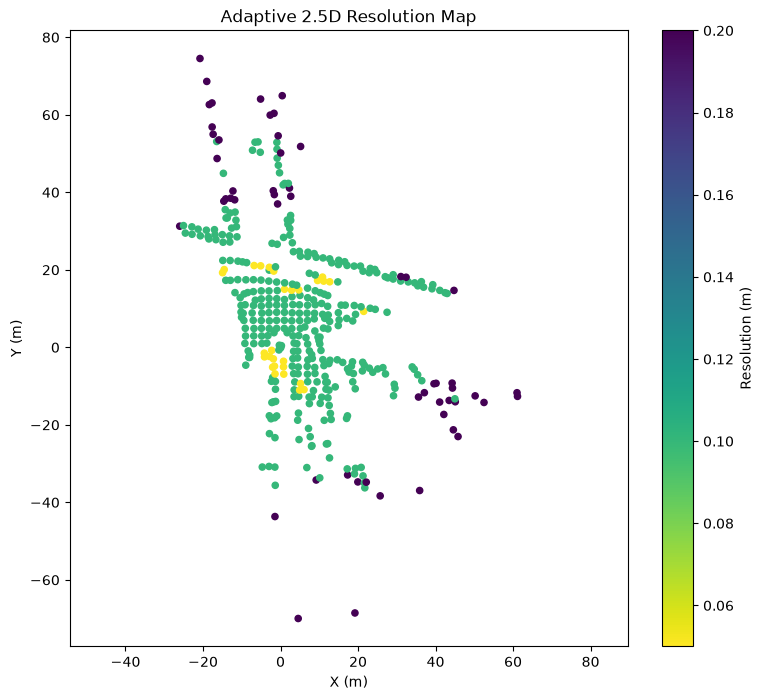

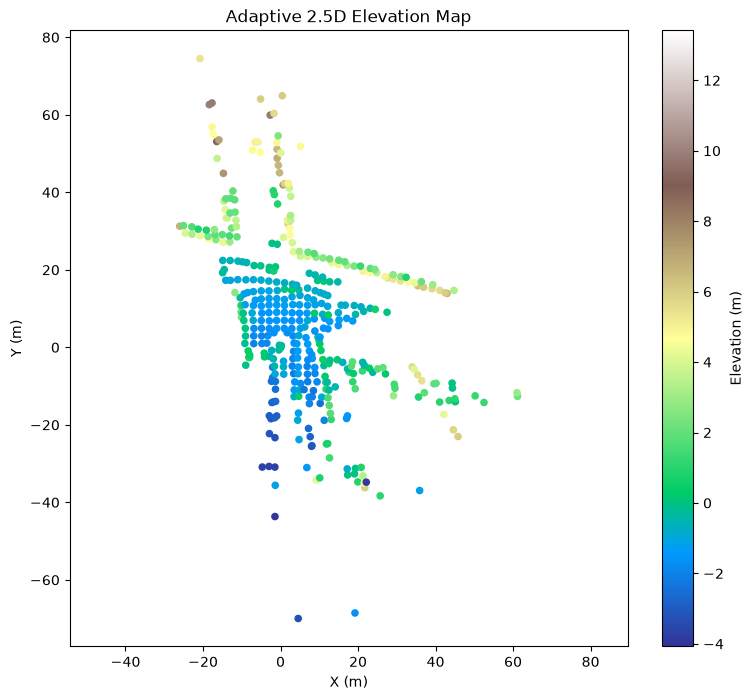

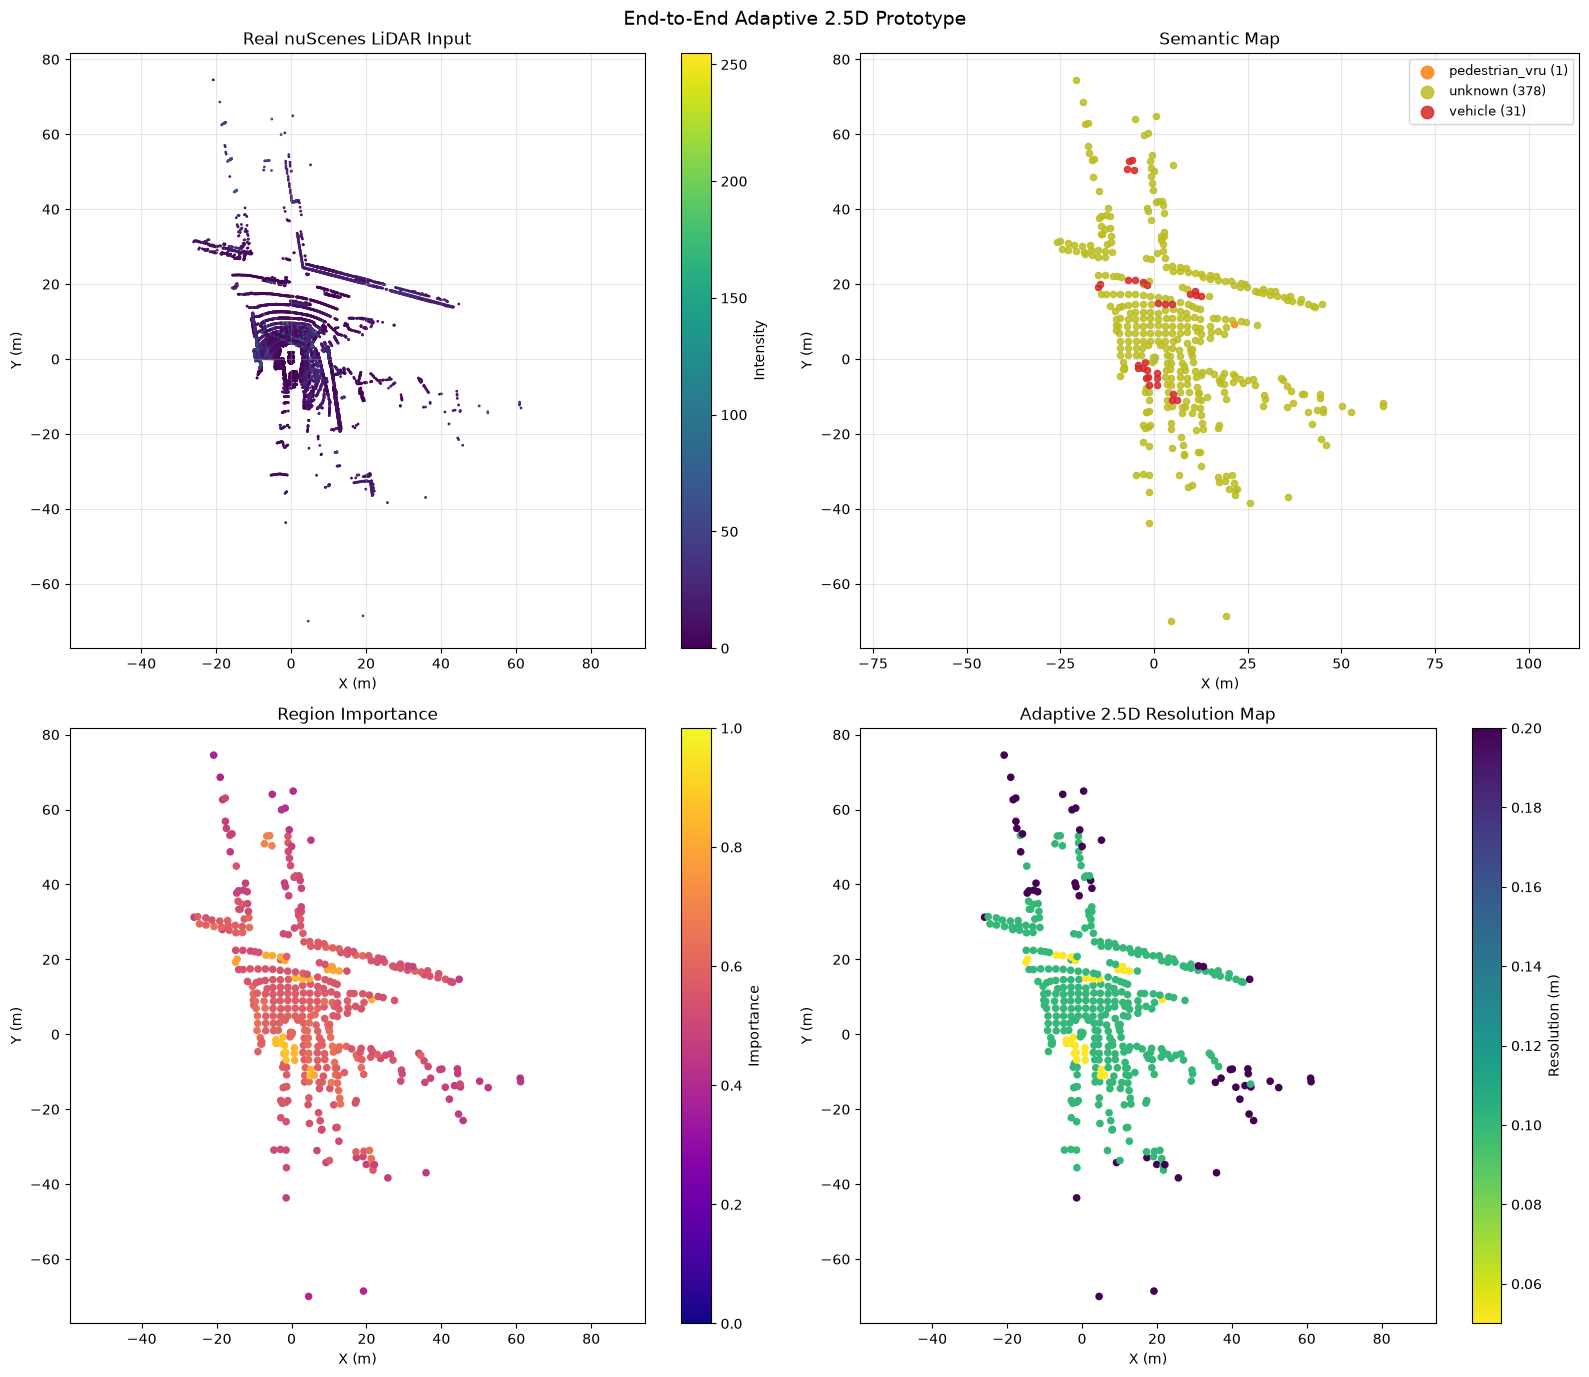

In [16]:
plot_lidar_xy(preprocessed_points, title="Real nuScenes LiDAR Input")
plt.savefig(os.path.join(FIGURES_ROOT, "12sep_raw_lidar.png"), dpi=200, bbox_inches="tight")
plt.show()

plot_semantic_regions(adaptive_map_df, title="Semantic Map — Real nuScenes Frame")
plt.savefig(os.path.join(FIGURES_ROOT, "12sep_semantic_map.png"), dpi=200, bbox_inches="tight")
plt.show()

plot_importance_map(adaptive_map_df)
plt.savefig(os.path.join(FIGURES_ROOT, "12sep_importance_map.png"), dpi=200, bbox_inches="tight")
plt.show()

plot_resolution_map(adaptive_map_df)
plt.savefig(os.path.join(FIGURES_ROOT, "12sep_resolution_map.png"), dpi=200, bbox_inches="tight")
plt.show()

plot_elevation_map(adaptive_map_df)
plt.savefig(os.path.join(FIGURES_ROOT, "12sep_elevation_map.png"), dpi=200, bbox_inches="tight")
plt.show()

plot_combined_demo(preprocessed_points, adaptive_map_df)
plt.savefig(os.path.join(FIGURES_ROOT, "12sep_combined_demo.png"), dpi=200, bbox_inches="tight")
plt.show()

## 17. Map statistics + resolution allocation (descriptive prototype statistics, not benchmarks)


In [17]:
stats = map_statistics(adaptive_map_df)
print("Map cells:", stats["num_cells"])
print("Occupied cells:", stats["occupied_cells"])
print("Mean importance:", stats["mean_importance"])
print("\nResolution distribution:")
print(adaptive_map_df["resolution"].value_counts().sort_index())
print("\nResolution allocation (%):")
print({k: round(v, 2) for k, v in stats["resolution_percentage"].items()})

Map cells: 410
Occupied cells: 410
Mean importance: 0.5765337976540518

Resolution distribution:
resolution
0.05     28
0.10    328
0.20     54
Name: count, dtype: int64

Resolution allocation (%):
{0.05: 6.83, 0.1: 80.0, 0.2: 13.17}


## 18. Processing latency (core pipeline only — visualization excluded) + equivalent rate


In [18]:
start = time.perf_counter()
_pts2, _ = preprocess_points(raw_processed_points)
_s = nusc.get("sample", sample_token)
_lab, _sarr, _ = assign_annotation_semantics(
    _pts2, annotations_to_sensor_frame(nusc, _s))
_pr, _src, _ = build_perception_from_semantics(
    str(frame_metadata["frame_id"]), _pts2, _lab, _sarr)
_regs, _det = aggregate_to_regions(_pr, _src, cell_size=CELL_SIZE)
_cells, _df = build_adaptive_map(_regs, importance_engine, resolution_engine, _det)
end = time.perf_counter()
pipeline_latency_ms = (end - start) * 1000.0
fps_equivalent = 1000.0 / pipeline_latency_ms
print(f"Pipeline latency: {pipeline_latency_ms:.2f} ms")
print(f"Equivalent processing rate: {fps_equivalent:.2f} FPS")
print("Equivalent processing rate under the tested Colab/runtime configuration.")


Pipeline latency: 962.38 ms
Equivalent processing rate: 1.04 FPS
Equivalent processing rate under the tested Colab/runtime configuration.


## 19. Multi-frame reliability test (2–3 real frames, failures recorded not ignored)


In [19]:
pipeline_records = []
for pf in processed_files[:3]:
    tok = pf.replace("_LIDAR_TOP_xyzi.npy", "")
    pts_raw = np.load(os.path.join(PROCESSED_ROOT, pf))
    meta = pd.read_csv(os.path.join(PROCESSED_ROOT, f"{tok}_metadata.csv")).iloc[0].to_dict()
    t0 = time.perf_counter()
    try:
        pts, _ = preprocess_points(pts_raw)
        assert pts.ndim == 2 and pts.shape[1] == 4 and len(pts) > 0
        assert np.isfinite(pts).all()
        s = nusc.get("sample", tok)
        lab, src_arr, _ = assign_annotation_semantics(
            pts, annotations_to_sensor_frame(nusc, s))
        pr, sa, _ = build_perception_from_semantics(str(meta["frame_id"]), pts, lab, src_arr)
        regs, det = aggregate_to_regions(pr, sa, cell_size=CELL_SIZE)
        _, mdf = build_adaptive_map(regs, importance_engine, resolution_engine, det)
        validate_adaptive_map_df(mdf)
        lat = (time.perf_counter() - t0) * 1000.0
        pipeline_records.append({
            "frame_id": str(meta["frame_id"]), "sample_token": tok,
            "input_points": len(pts_raw), "processed_points": len(pts),
            "region_count": len(regs), "map_cell_count": len(mdf),
            "mean_importance": float(mdf["importance"].mean()),
            "resolution_counts": str(dict(mdf["resolution"].value_counts().sort_index())),
            "pipeline_latency_ms": round(lat, 2),
            "fps_equivalent": round(1000.0 / lat, 2), "valid": True,
        })
    except Exception as e:
        pipeline_records.append({
            "frame_id": str(meta.get("frame_id", "")), "sample_token": tok,
            "input_points": len(pts_raw), "processed_points": 0,
            "region_count": 0, "map_cell_count": 0, "mean_importance": float("nan"),
            "resolution_counts": "{}", "pipeline_latency_ms": float("nan"),
            "fps_equivalent": float("nan"), "valid": f"FAIL: {e}",
        })
pipeline_metrics_df = pd.DataFrame(pipeline_records)
display(pipeline_metrics_df)

,frame_id,sample_token,input_points,processed_points,region_count,map_cell_count,mean_importance,resolution_counts,pipeline_latency_ms,fps_equivalent,valid
0,00889f8a9549450aa2f32cf310a3e305,00889f8a9549450aa2f32cf310a3e305,34658,34658,410,410,0.576534,"{0.05: np.int64(28), 0.1: np.int64(328), 0.2: ...",705.11,1.42,True
1,0106a9b8e65f4ad1867b44591aeed8b0,0106a9b8e65f4ad1867b44591aeed8b0,34589,34589,1105,1105,0.510395,"{0.05: np.int64(10), 0.1: np.int64(654), 0.2: ...",951.50,1.05,True
2,023c4df2d451409881d8e6ea82f14704,023c4df2d451409881d8e6ea82f14704,34653,34653,1060,1060,0.513958,"{0.05: np.int64(31), 0.1: np.int64(583), 0.2: ...",1118.18,0.89,True


## 20. Save outputs + final automated end-to-end validation


In [20]:
adaptive_map_df.to_csv(os.path.join(RESULTS_ROOT, "12sep_adaptive_map.csv"), index=False)
metrics = {
    "sample_token": sample_token,
    "input_points": len(raw_processed_points),
    "processed_points": len(preprocessed_points),
    "regions": len(region_features),
    "map_cells": len(adaptive_map_df),
    "mean_importance": adaptive_map_df["importance"].mean(),
    "pipeline_latency_ms": pipeline_latency_ms,
    "fps_equivalent": fps_equivalent,
}
pd.DataFrame([metrics]).to_csv(
    os.path.join(RESULTS_ROOT, "12sep_pipeline_metrics.csv"), index=False)
pipeline_metrics_df.to_csv(
    os.path.join(RESULTS_ROOT, "preprocessing_reliability_12sep.csv"), index=False)
print("Saved: 12sep_adaptive_map.csv, 12sep_pipeline_metrics.csv, "
      "preprocessing_reliability_12sep.csv + figures/")

assert len(preprocessed_points) > 0
assert preprocessed_points.ndim == 2
assert preprocessed_points.shape[1] == 4
assert np.isfinite(preprocessed_points).all()
assert len(region_features) > 0
for region in region_features:
    validate_region_features(region)
assert len(adaptive_map_df) == len(region_features)
assert adaptive_map_df["importance"].between(0.0, 1.0).all()
assert adaptive_map_df["resolution"].isin([0.05, 0.10, 0.20, 0.50]).all()
assert (adaptive_map_df["occupancy"] >= 0).all()
assert sample_token == frame_metadata["sample_token"]
print("12 SEPTEMBER END-TO-END PROTOTYPE: PASS")

Saved: 12sep_adaptive_map.csv, 12sep_pipeline_metrics.csv, preprocessing_reliability_12sep.csv + figures/
12 SEPTEMBER END-TO-END PROTOTYPE: PASS
